In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Generalization

Consider two college students diligently
preparing for their final exam.
Commonly, this preparation will consist
of practicing and testing their abilities
by taking exams administered in previous years.
Nonetheless, doing well on past exams is no guarantee
that they will excel when it matters.
For instance, imagine a student, Extraordinary Ellie,
whose preparation consisted entirely
of memorizing the answers
to previous years' exam questions.
Even if Ellie were endowed
with an extraordinary memory,
and thus could perfectly recall the answer
to any *previously seen* question,
she might nevertheless freeze
when faced with a new (*previously unseen*) question.
By comparison, imagine another student,
Inductive Irene, with comparably poor
memorization skills,
but a knack for picking up patterns.
Note that if the exam truly consisted of
recycled questions from a previous year,
Ellie would handily outperform Irene.
Even if Irene's inferred patterns
yielded 90% accurate predictions,
they could never compete with
Ellie's 100% recall.
However, even if the exam consisted
entirely of fresh questions,
Irene might maintain her 90% average.

As machine learning scientists,
our goal is to discover *patterns*.
But how can we be sure that we have
truly discovered a *general* pattern
and not simply memorized our data?
Most of the time, our predictions are only useful
if our model discovers such a pattern.
We do not want to predict yesterday's stock prices, but tomorrow's.
We do not need to recognize
already diagnosed diseases
for previously seen patients,
but rather previously undiagnosed
ailments in previously unseen patients.
This problem (how to discover patterns that *generalize*) is
the fundamental problem of machine learning,
and arguably of all of statistics.
We might cast this problem as just one slice
of a far grander question
that engulfs all of science:
when are we ever justified
in making the leap from particular observations
to more general statements?


In real life, we must fit our models
using a finite collection of data.
The typical scales of that data
vary wildly across domains.
For many important medical problems,
we can only access a few thousand data points.
When studying rare diseases,
we might be lucky to access hundreds.
By contrast, the largest public datasets
consisting of labeled photographs,
e.g., ImageNet [@Deng.Dong.Socher.ea.2009],
contain millions of images.
And some unlabeled image collections
such as the Flickr YFC100M dataset
can be even larger, containing
over 100 million images [@thomee2016yfcc100m].
However, even at this extreme scale,
the number of available data points
remains infinitesimally small
compared to the space of all possible images
at a megapixel resolution.
Whenever we work with finite samples,
we must keep in mind the risk
that we might fit our training data,
only to discover that we failed
to discover a generalizable pattern.

The phenomenon of fitting closer to our training data
than to the underlying distribution is called *overfitting*,
and techniques for combatting overfitting
are often called *regularization* methods.
While it is no substitute for a proper introduction
to statistical learning theory (that section
gives a first, rigorous taste; see also @Vapnik98; @boucheron2005theory),
we will give you just enough intuition to get going.
We will revisit generalization in many chapters
throughout the book,
exploring both what is known about
the principles underlying generalization
in various models,
and also heuristic techniques
that have been found (empirically)
to yield improved generalization
on tasks of practical interest.


## Training Error and Generalization Error


In the standard supervised learning setting,
we assume that the training data and the test data
are drawn *independently* from *identical* distributions.
This is commonly called the *IID assumption*.
While this assumption is strong,
absent any such assumption we would be dead in the water.
Why should we believe that training data
sampled from distribution $P(X,Y)$
should tell us how to make predictions on
test data generated by a *different distribution* $Q(X,Y)$?
Making such leaps turns out to require
strong assumptions about how $P$ and $Q$ are related.
Later on we will discuss some assumptions
that allow for shifts in distribution
but first we need to understand the IID case,
where $P(\cdot) = Q(\cdot)$.

To begin with, we need to differentiate between
the *training error* $R_\textrm{emp}$,
which is a *statistic*
calculated on the training dataset,
and the *generalization error* $R$,
which is an *expectation* taken
with respect to the underlying distribution.
You can think of the generalization error as
what you would see  if you applied your model
to an infinite stream of additional data examples
drawn from the same underlying data distribution.
Formally the training error is expressed as an *average* over the finite training sample (with the same notation as that section):

$$R_\textrm{emp}[\mathbf{X}, \mathbf{y}, f] = \frac{1}{n} \sum_{i=1}^n l(\mathbf{x}^{(i)}, y^{(i)}, f(\mathbf{x}^{(i)})),$$


while the generalization error (also called the *risk*) is expressed as an integral:

$$R[P, f] = E_{(\mathbf{x}, y) \sim P} [l(\mathbf{x}, y, f(\mathbf{x}))] = \int \int l(\mathbf{x}, y, f(\mathbf{x})) p(\mathbf{x}, y) \;d\mathbf{x} dy.$$

Problematically, we can never calculate
the generalization error $R$ exactly.
Nobody ever tells us the precise form
of the density function $p(\mathbf{x}, y)$.
Moreover, we cannot sample an infinite stream of data points.
Thus, in practice, we must *estimate* the generalization error
by applying our model to an independent test set
constituted of a random selection of examples
$\mathbf{X}'$ and labels $\mathbf{y}'$
that were withheld from our training set.
This consists of applying the same formula
that was used for calculating the empirical training error
but to a test set $\mathbf{X}', \mathbf{y}'$.


Crucially, when we evaluate our model on the test set,
we are working with a *fixed* model
(it does not depend on the sample of the test set),
and thus estimating its error
is simply the problem of mean estimation.
However the same cannot be said
for the training set.
Note that the model we wind up with
depends explicitly on the selection of the training set
and thus the training error will in general
be a biased estimate of the true error
on the underlying population.
The central question of generalization
is then when should we expect our training error
to be close to the population error
(and thus the generalization error).

### Model Complexity

In classical theory, when we have
simple models and abundant data,
the training and generalization errors tend to be close.
However, when we work with
more complex models and/or fewer examples,
we expect the training error to go down
but the *generalization gap* (the difference $R - R_\textrm{emp}$
between the generalization error and the training error) to grow.
This should not be surprising.
Imagine a model class so expressive that
for any dataset of $n$ examples,
we can find a set of parameters
that can perfectly fit arbitrary labels,
even if randomly assigned.
In this case, even if we fit our training data perfectly,
how can we conclude anything about the generalization error?
For all we know, our generalization error
might be no better than random guessing.

In general, absent any restriction on our model class,
we cannot conclude, based on fitting the training data alone,
that our model has discovered any generalizable pattern [@vapnik1994measuring].
On the other hand, if our model class
was not capable of fitting arbitrary labels,
then low training error is evidence that it has captured a real pattern,
provided the sample is large relative to the class's capacity
(that section).
Learning-theoretic ideas about model complexity
derived some inspiration from the ideas
of Karl Popper, an influential philosopher of science,
who formalized the criterion of falsifiability [@popper2005logic].
According to Popper, a theory
that can explain any and all observations
is not a scientific theory at all!
After all, what has it told us about the world
if it has not ruled out any possibility?
In short, what we want is a hypothesis
that *could not* explain any observations
we might conceivably make
and yet nevertheless happens to be compatible
with those observations that we *in fact* make.

Now what precisely constitutes an appropriate
notion of model complexity is a complex matter.
For squared-error regression, with expectation taken over repeated training
sets drawn by the same process, the classical *bias-variance decomposition*
makes the trade-off precise: a model too simple to capture the signal makes a systematic error
(high *bias*, i.e., underfitting), while a model flexible enough to chase the
noise in a particular training set varies wildly from one dataset to the next
(high *variance*, i.e., overfitting). Their sum, plus an irreducible noise floor
$\sigma^2$, is the expected test error, which traces the U-shaped curve of
the figure; we derive the decomposition formally in
that section.
Often, models with more parameters
are able to fit a greater number
of arbitrarily assigned labels.
However, this is not necessarily true.
For instance, kernel methods operate in spaces
with infinite numbers of parameters,
yet their complexity is controlled
by other means [@Scholkopf.Smola.2002].
One notion of complexity that often proves useful
is the range of values that the parameters can take.
Here, a model whose parameters are permitted
to take arbitrary values
would be more complex.
We will revisit this idea in the next section,
when we introduce *weight decay*,
your first practical regularization technique.
It can be difficult to compare
complexity among members of substantially different model classes
(say, decision trees vs. neural networks).


At this point, we must stress another important point
that we will revisit when introducing deep neural networks.
When a model is capable of fitting arbitrary labels,
low training error does not necessarily
imply low generalization error.
*However, it does not necessarily
imply high generalization error either!*
All we can say with confidence is that
low training error alone is not enough
to certify low generalization error.
Deep neural networks turn out to be just such models:
while they generalize well in practice,
they are too powerful to allow us to conclude
much on the basis of training error alone.
In these cases we must rely more heavily
on our holdout data to certify generalization
after the fact.
Error on the holdout data, i.e., validation set,
is called the *validation error*.

This classical picture, in which more *capacity* (the richness of the model
class) means more overfitting, is, however,
*incomplete* for the heavily overparametrized models at the heart of modern deep
learning. Once a model is large enough to *interpolate* its training data (drive
training error to zero), pushing capacity even higher often makes test error
*fall again* rather than rise: the *double descent* phenomenon
[@Belkin.Hsu.Ma.ea.2019; @nakkiran2021deep]. We take up this modern story, and
why the classical complexity intuition breaks down, in
that section; for a quantitative treatment that
reproduces the double-descent curve from scratch, see
that section.

## Underfitting or Overfitting?

When we compare the training and validation errors,
we want to be mindful of two common situations.
First, we want to watch out for cases
when our training error and validation error are both substantial
but there is only a small gap between them.
If the model is unable to reduce the training error,
that could mean that our model is too simple
(i.e., insufficiently expressive)
to capture the pattern that we are trying to model.
Moreover, since the generalization gap
between our training and generalization errors is small,
we have reason to believe that we could get away with a more complex model.
This phenomenon is known as *underfitting*.

On the other hand, as we discussed above,
we want to watch out for the cases
when our training error is significantly lower
than our validation error, indicating severe *overfitting*.
Note that overfitting is not always a bad thing.
In deep learning especially,
the best predictive models often perform
far better on training data than on holdout data.
Ultimately, we usually care about
driving the generalization error lower,
and only care about the gap insofar
as it becomes an obstacle to that end.
Note that if the training error is zero,
then the generalization gap is precisely equal to the generalization error
and we can make progress only by reducing the gap.

### Polynomial Curve Fitting

To illustrate some classical intuition
about overfitting and model complexity,
consider the following:
given training data consisting of a single feature $x$
and a corresponding real-valued label $y$,
we try to find the polynomial of degree $d$

$$\hat{y}= \sum_{i=0}^d x^i w_i$$

for estimating the label $y$.
This is just a linear regression problem
where our features are given by the powers of $x$,
the model's weights are given by $w_i$,
and the bias is given by $w_0$ since $x^0 = 1$ for all $x$.
Since this is just a linear regression problem,
we can use the squared error as our loss function.


A higher-order polynomial function is more complex
than a lower-order polynomial function,
since the higher-order polynomial has more parameters
and the model function's selection range is wider.
Fixing the training dataset,
higher-order polynomial functions should always
achieve lower (at worst, equal) training error
relative to lower-degree polynomials.
In fact, whenever each data example
has a distinct value of $x$,
a polynomial function with degree
equal to the number of data examples
can fit the training set perfectly.
We compare the relationship between polynomial degree (model complexity)
and both underfitting and overfitting in the figure.

![Influence of model complexity on underfitting and overfitting: as complexity grows, squared bias falls while variance rises, and their sum (plus an irreducible noise floor) is the expected test error, which traces a U.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-bias-variance-u-curve.svg)

To see this concretely, let us generate data from a known cubic and fit
polynomials of growing degree to a small training set.

In [1]:
%matplotlib inline
import math
import numpy as np
from d2l import torch as d2l

We draw inputs $x$ uniformly from $[-1, 1]$, build a design matrix whose $i$-th
column is $x^i$, and generate labels from a degree-3 target
$y = 5 + 1.2 x - 3.4 x^2 + 5.6 x^3$ plus a little Gaussian noise. We deliberately
keep the training set small so that high-degree models have room to overfit.

In [2]:
np.random.seed(0)
max_degree = 20                  # highest polynomial degree we will fit
n_train, n_test = 20, 100        # few training points, so high degrees overfit
true_w = np.zeros(max_degree)
true_w[:4] = np.array([5, 1.2, -3.4, 5.6])

x = np.random.uniform(-1, 1, size=n_train + n_test)
poly = np.power(x.reshape(-1, 1), np.arange(max_degree))   # column i holds x**i
labels = poly @ true_w + np.random.normal(scale=0.1, size=n_train + n_test)

Fitting the first $d+1$ columns by least squares gives the best degree-$d$
polynomial; we record its loss on both the training and the held-out test split.

In [3]:
def fit_degree(d):
    cols = slice(0, d + 1)
    w, *_ = np.linalg.lstsq(poly[:n_train, cols], labels[:n_train], rcond=None)
    err = poly[:, cols] @ w - labels
    return (err[:n_train] ** 2).mean(), (err[n_train:] ** 2).mean()

A degree-1 polynomial is too rigid to capture a cubic, so it errs on both splits
(*underfitting*); degree 3 matches the true model, with low error on both; and a
degree-19 polynomial has enough freedom to interpolate the 20 training points
almost exactly, driving training error toward zero while test error explodes
(*overfitting*).

In [4]:
for name, d in [('underfitting (degree 1) ', 1),
                ('just right   (degree 3) ', 3),
                ('overfitting   (degree 19)', 19)]:
    train_mse, test_mse = fit_degree(d)
    print(f'{name}: train {train_mse:8.4f}   test {test_mse:12.4f}')

underfitting (degree 1) : train   1.6698   test       1.7318
just right   (degree 3) : train   0.0136   test       0.0129
overfitting   (degree 19): train   0.0000   test 49271508224071.6328


Sweeping the degree from 1 to 19 traces out exactly the U-shaped test-error curve
that the figure sketches: error first falls as the model
gains the capacity to represent the signal, then rises as the surplus capacity is
spent fitting noise. Training error, by contrast, only ever decreases.

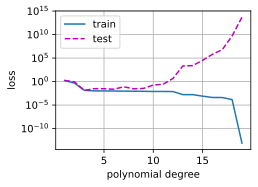

In [5]:
degrees = list(range(1, max_degree))
mse = np.array([fit_degree(d) for d in degrees])
d2l.plot(degrees, [mse[:, 0], mse[:, 1]], xlabel='polynomial degree',
         ylabel='loss', legend=['train', 'test'], yscale='log')

So far we have *named* bias and variance; this experiment has everything we
need to *compute* them. Because we know the noiseless target
$f(x) = 5 + 1.2 x - 3.4 x^2 + 5.6 x^3$, we can redraw the training noise many
times, refit the degree-$d$ polynomial on each draw, and ask two questions on
the held-out inputs: how far is the *average* fit from the truth
(squared bias), and how much does the fit *fluctuate* across draws (variance)?

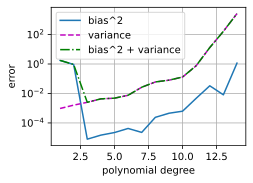

In [6]:
f = poly @ true_w                        # noiseless target on all inputs
bias2, var = [], []
for d in range(1, 15):
    preds = []
    for _ in range(200):                 # 200 fresh draws of training noise
        y_tr = f[:n_train] + np.random.normal(scale=0.1, size=n_train)
        w, *_ = np.linalg.lstsq(poly[:n_train, :d+1], y_tr, rcond=None)
        preds.append(poly[n_train:, :d+1] @ w)
    preds = np.stack(preds)
    bias2.append(((preds.mean(0) - f[n_train:]) ** 2).mean())
    var.append(preds.var(0).mean())
d2l.plot(list(range(1, 15)), [bias2, var, np.array(bias2) + np.array(var)],
         xlabel='polynomial degree', ylabel='error', yscale='log',
         legend=['bias^2', 'variance', 'bias^2 + variance'])

The U-curve now *visibly decomposes*. Squared bias dominates for degrees below
3 and collapses to essentially zero the moment the model class contains the
truth; variance is tiny at first but grows relentlessly with surplus capacity,
exploding as the polynomial gains the freedom to chase each draw's noise. Their
sum (which, up to the irreducible noise floor $\sigma^2 = 0.01$, is the
expected test error) is lowest exactly where the two failure modes trade off,
at degree 3. This is a numerical instance of the decomposition proved in
that section.

### Dataset Size

Beyond model complexity,
another big consideration
to bear in mind is dataset size.
Fixing our model, the fewer samples
we have in the training dataset,
the more likely (and more severely)
we are to encounter overfitting.
As we increase the amount of training data,
the generalization error typically decreases when the learning procedure and
data distribution are held fixed. This is a tendency, not a monotonic law:
unstable procedures and interpolation thresholds can produce temporary
increases, including the sample-wise double descent discussed later.
For a fixed task and data distribution,
model complexity should not increase
more rapidly than the amount of data.
Given more data, we might  attempt
to fit a more complex model.
Absent sufficient data, simpler models
may be more difficult to beat.
For many tasks, deep learning
only outperforms linear models
when many thousands of training examples are available.
In part, the current success of deep learning
owes considerably to the abundance of massive datasets
arising from Internet companies, cheap storage,
connected devices, and the broad digitization of the economy.

## Model Selection

Typically, we select our final model
only after evaluating multiple models
that differ in various ways
(different architectures, training objectives,
selected features, data preprocessing,
learning rates, etc.).
Choosing among many models is aptly
called *model selection*.

In principle, we should not touch our test set
until after we have chosen all our hyperparameters.
Were we to use the test data in the model selection process,
there is a risk that we might overfit the test data.
Then we would be in serious trouble.
If we overfit our training data,
there is always the evaluation on test data to keep us honest.
But if we overfit the test data, how would we ever know?
See @ong2005learning for an example of how
this can lead to absurd results even for models where the complexity
can be tightly controlled.

Thus, we should never rely on the test data for model selection.
And yet we cannot rely solely on the training data
for model selection either because
we cannot estimate the generalization error
on the very data that we use to train the model.


In practical applications, the picture gets muddier.
While ideally we would only touch the test data once,
to assess the very best model or to compare
a small number of models with each other,
real-world test data is seldom discarded after just one use.
We can seldom afford a new test set for each round of experiments.
In fact, recycling benchmark data for decades
can have a significant impact on the
development of algorithms, as documented when researchers rebuilt fresh test
sets for long-standing benchmarks and watched accuracy drop
[@Recht.Roelofs.Schmidt.ea.2019]. This effect is visible, e.g., for
[image classification](https://paperswithcode.com/sota/image-classification-on-imagenet)
and [optical character recognition](https://paperswithcode.com/sota/image-classification-on-mnist).

The common practice for addressing the problem of *training on the test set*
is to split our data three ways,
incorporating a *validation set*
in addition to the training and test datasets.
The result is a murky business where the boundaries
between validation and test data are worryingly ambiguous.
Unless explicitly stated otherwise, in the experiments in this book
we are really working with what should rightly be called
training data and validation data, with no true test sets.
Therefore, the accuracy reported in each experiment of the book is really
the validation accuracy and not a true test set accuracy.

### Cross-Validation

When training data is scarce,
we might not even be able to afford to hold out
enough data to constitute a proper validation set.
One popular solution to this problem is to employ
$K$*-fold cross-validation*.
Here, the original training data is split into $K$ non-overlapping subsets.
Then model training and validation are executed $K$ times,
each time training on $K-1$ subsets and validating
on a different subset (the one not used for training in that round).
Finally, the training and validation errors are estimated
by averaging over the results from the $K$ experiments.
The procedure is illustrated in the figure.

![In $K$-fold cross-validation, each of the $K$ folds serves once as the validation set (orange) while the model trains on the remaining folds (blue); the final estimate averages the $K$ validation scores.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-mlp-kfold.svg)

How should we choose $K$? The choice trades off bias, variance, and compute.
Each fold's model is trained on only $(K-1)/K$ of the data. If the learning
curve improves monotonically with sample size, its error is higher than that
of the model finally trained on all the data, making the cross-validation
estimate pessimistic. This conclusion is not guaranteed for unstable or
non-monotone learning procedures.
Taking $K = n$ (*leave-one-out* cross-validation) all but eliminates this bias,
but at a steep price: it requires $n$ model fits, and the $n$ training sets
are nearly identical, so the fold errors are highly correlated and their
average tends to have higher variance; in fact no general unbiased estimator
of the cross-validation variance exists [@Bengio.Grandvalet.2004].
The standard compromise, $K = 5$ or $K = 10$, keeps the bias modest, averages
over reasonably distinct training sets, and costs only $5$--$10$ fits, which is
why these values dominate practice [@Kohavi.1995].
(Exercises 4 and 5 ask you to reason through the cost and the bias.)


## Summary

This section explored some of the  underpinnings
of generalization in  machine learning.
Some of these ideas become complicated
and counterintuitive when we get to deeper models; here, models are capable of overfitting data badly,
and the relevant notions of complexity
can be both implicit and counterintuitive
(e.g., larger architectures with more parameters
generalizing better).
We leave you with a few rules of thumb:

1. Use validation sets (or $K$*-fold cross-validation*) for model selection;
1. More complex models often require more data;
1. Relevant notions of complexity include both the number of parameters and the range of values that they are allowed to take;
1. Keeping the learning procedure and data distribution fixed, more data usually improves generalization, but the curve need not be monotone;
1. This entire talk of generalization is all predicated on the IID assumption. If we relax this assumption, allowing for distributions to shift between the train and testing periods, then we cannot say anything about generalization absent a further (perhaps milder) assumption.


## Exercises

1. When can you solve the problem of polynomial regression exactly?
1. Give at least five examples where dependent random variables make treating the problem as IID data inadvisable.
1. Can you ever expect to see zero training error? Under which circumstances would you see zero generalization error?
1. Why is $K$-fold cross-validation very expensive to compute?
1. Why is the $K$-fold cross-validation error estimate biased?
1. The VC dimension is defined as the maximum number of points that can be classified with arbitrary labels $\{\pm 1\}$ by a function of a class of functions. Why might this not be a good idea for measuring how complex the class of functions is? Hint: consider the magnitude of the functions.
1. Your manager gives you a difficult dataset on which your current algorithm does not perform so well. How would you justify to him that you need more data? Hint: you cannot increase the data but you can decrease it.
1. Re-run the polynomial-fitting experiment above with `n_train` set to 10, 40, and 100. At what degree does the test loss start to climb in each case? Relate your finding to the rule of thumb that more complex models require more data.

[Discussions](https://d2l.discourse.group/t/97)